In [56]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [57]:
# %%
FONT_SIZE = 8
plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.transparent': True,
    'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
    'font.size': FONT_SIZE, 'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE, 'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE, 'legend.fontsize': FONT_SIZE,
})

In [58]:
# %%
# Load forward TRFs for all subjects
SUBJECTS = helper_functions.get_subjects()

checks = [
    # Single predictors
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, True),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, True),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),

    # Multiple predictors
    ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
]


trf_data, n_subjects = helper_functions.load_trfs(checks, trf_dir=MAT_FILE_TRF_DIR)
self_trf_data, n_subjects = helper_functions.load_trfs(checks, trf_dir=SELF_COMPUTED_TRF_DIR)

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects
  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects


In [59]:
# %%
# Extract mean r per subject for each condition
def mean_r(name, self_computed = False):
    if self_computed:
          return [trf.r.mean() for trf in self_trf_data[name]]
    else:
         return[trf.r.mean() for trf in trf_data[name]]


r = {
     helper_functions.get_trf_model_name(p, a, m, pad): mean_r(helper_functions.get_trf_model_name(p, a, m, pad), self_computed=False)
     for p, a, m, pad in checks
}
self_r = {
     helper_functions.get_trf_model_name(p, a, m, pad): mean_r(helper_functions.get_trf_model_name(p, a, m, pad), self_computed=True)
     for p, a, m, pad in checks
}

names = list(r.keys())
self_names = list(self_r.keys())


Condition              Imported       Self       Diff    p-value   sig
----------------------------------------------------------------------
Att. Envelope            0.0271     0.0305    -0.0034     0.0009   ***
Ign. Envelope            0.0183     0.0225    -0.0041     0.0015    **
Att. Env+Onset           0.0315     0.0342    -0.0027     0.0009   ***
Ign. Env+Onset           0.0192     0.0237    -0.0045     0.0002   ***


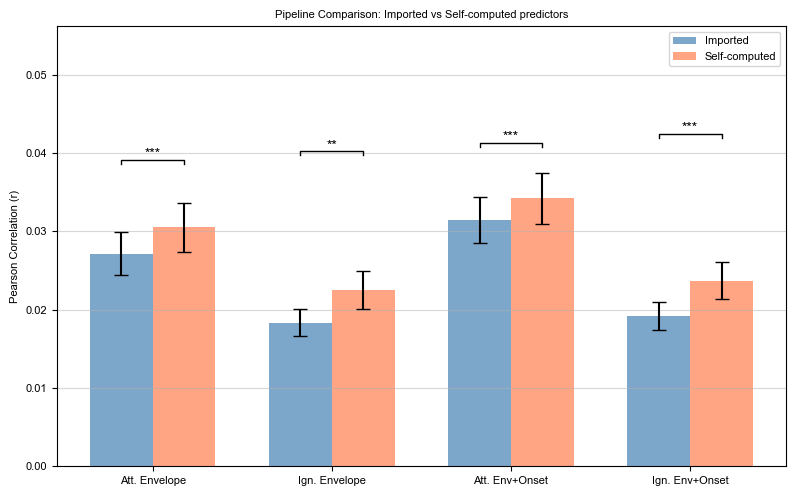

In [60]:
def compare_pipelines(r, self_r):
    """
    Compare imported vs self-computed pipeline for matched conditions.
    """
    conditions = {
        'Att. Envelope':       helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,                                  ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
        'Ign. Envelope':       helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,                                  ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
        'Att. Env+Onset':      helper_functions.get_trf_model_name([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
        'Ign. Env+Onset':      helper_functions.get_trf_model_name([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
    }

    labels       = list(conditions.keys())
    names        = list(conditions.values())
    imported_means = [np.mean(r[n])      for n in names]
    self_means     = [np.mean(self_r[n]) for n in names]
    imported_sems  = [stats.sem(r[n])      for n in names]
    self_sems      = [stats.sem(self_r[n]) for n in names]

    tests = {}
    print(f"{'Condition':<20} {'Imported':>10} {'Self':>10} {'Diff':>10} {'p-value':>10} {'sig':>5}")
    print("-" * 70)
    for label, name in conditions.items():
        t, p         = stats.ttest_rel(r[name], self_r[name])
        tests[label] = (t, p)
        print(f"{label:<20} {np.mean(r[name]):>10.4f} {np.mean(self_r[name]):>10.4f} {np.mean(r[name]) - np.mean(self_r[name]):>10.4f} {p:>10.4f} {helper_functions.sig_marker(p):>5}")

    # Plot
    x     = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars_imported = ax.bar(x - width/2, imported_means, width, yerr=imported_sems, capsize=5, color='steelblue', alpha=0.7, label='Imported')
    bars_self     = ax.bar(x + width/2, self_means,     width, yerr=self_sems,     capsize=5, color='coral',     alpha=0.7, label='Self-computed')

    y_max = max(m + s for m, s in zip(imported_means + self_means, imported_sems + self_sems))
    for i, (label, (t, p)) in enumerate(tests.items()):
        helper_functions.add_sig_line(ax, i - width/2, i + width/2, y_max + 0.03 * y_max * (i + 1), helper_functions.sig_marker(p))

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Pearson Correlation (r)')
    ax.set_title('Pipeline Comparison: Imported vs Self-computed predictors')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.5)
    ax.set_ylim(0, y_max * 1.5)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'{FUGLSANG}_pipeline_comparison.png', bbox_inches='tight')
    plt.show()

    return tests

pipeline_tests = compare_pipelines(r, self_r)